<a href="https://colab.research.google.com/github/Shedjohn/Time_series_STOCK-with-LSTM/blob/main/Time_series_Stock_prices_with_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("google_drive")

Mounted at google_drive


In [2]:
import pandas as pd
df =pd.read_csv("/content/google_drive/MyDrive/Datasets/all_stocks_5yr.csv")

**Inspect the Dataset**

In [3]:
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 33.1+ MB


In [5]:
df.describe()

,open,high,low,close,volume
count,619029.000000,619032.000000,619032.000000,619040.000000,6.190400e+05
mean,83.023334,83.778311,82.256096,83.043763,4.321823e+06
std,97.378769,98.207519,96.507421,97.389748,8.693610e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,40.220000,40.620000,39.830000,40.245000,1.070320e+06
50%,62.590000,63.150000,62.020000,62.620000,2.082094e+06
75%,94.370000,95.180000,93.540000,94.410000,4.284509e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [6]:
df.shape

(619040, 7)

**Check Missing Values**

In [7]:
df.isna().sum()

,0
date,0
open,11
high,8
low,8
close,0
volume,0
Name,0


In [8]:
missing_perc = (df.isnull().sum() / len(df)) * 100
missing_perc

,0
date,0.000000
open,0.001777
high,0.001292
low,0.001292
close,0.000000
volume,0.000000
Name,0.000000


In [9]:
#Inspect Missing Rows
df[df.isnull().any(axis=1)]

,date,open,high,low,close,volume,Name
82949,2017-07-26,NaN,NaN,NaN,69.0842,3,BHF
165734,2015-07-17,NaN,88.76,88.24,88.7200,2056819,DHR
165857,2016-01-12,NaN,NaN,NaN,88.5500,0,DHR
205076,2015-07-17,NaN,48.49,47.85,47.9200,1246786,ES
239832,2016-07-01,NaN,NaN,NaN,49.5400,0,FTV
434379,2015-07-17,NaN,47.31,46.83,46.9900,1229513,O
434502,2016-01-12,NaN,NaN,NaN,52.4300,0,O
478594,2015-06-09,NaN,NaN,NaN,526.0900,12135,REGN
558213,2016-04-07,NaN,NaN,NaN,41.5600,0,UA
581906,2015-05-12,NaN,NaN,NaN,124.0800,569747,VRTX


In [10]:
df=df.dropna()

In [11]:
df.isna().sum()

,0
date,0
open,0
high,0
low,0
close,0
volume,0
Name,0


**Check Duplicates**

In [12]:
df.duplicated().sum()

np.int64(0)

**Understand the Time Series Data**

In [13]:
print("Number of Stocks:", df['Name'].nunique())

print("Start Date:", df['date'].min())
print("End Date:", df['date'].max())

df['Name'].value_counts().head()

Number of Stocks: 505
Start Date: 2013-02-08
End Date: 2018-02-07


,count
Name,
ZTS,1259
AAL,1259
AAPL,1259
AAP,1259
ABBV,1259


**Let's create an Apple dataset.**

In [14]:
aapl = df[df['Name'] == "AAPL"].copy()
print(aapl.shape)
aapl.head()

(1259, 7)


,date,open,high,low,close,volume,Name
1259,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1260,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
1261,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
1262,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
1263,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


In [15]:
#sort by date
aapl = aapl.sort_values("date")
aapl.head()

,date,open,high,low,close,volume,Name
1259,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1260,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
1261,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
1262,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
1263,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


In [16]:
#Basic Time Series Inspection
aapl.info()
aapl.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 1259 entries, 1259 to 2517
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1259 non-null   object 
 1   open    1259 non-null   float64
 2   high    1259 non-null   float64
 3   low     1259 non-null   float64
 4   close   1259 non-null   float64
 5   volume  1259 non-null   int64  
 6   Name    1259 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 111.0+ KB


,open,high,low,close,volume
count,1259.000000,1259.000000,1259.000000,1259.000000,1.259000e+03
mean,109.055429,109.951118,108.141589,109.066698,5.404790e+07
std,30.549220,30.686186,30.376224,30.556812,3.346835e+07
min,55.424200,57.085700,55.014200,55.789900,1.147592e+07
25%,84.647800,85.334950,84.250650,84.830650,2.969438e+07
50%,108.970000,110.030000,108.050000,109.010000,4.566893e+07
75%,127.335000,128.100000,126.290000,127.120000,6.870872e+07
max,179.370000,180.100000,178.250000,179.260000,2.668336e+08


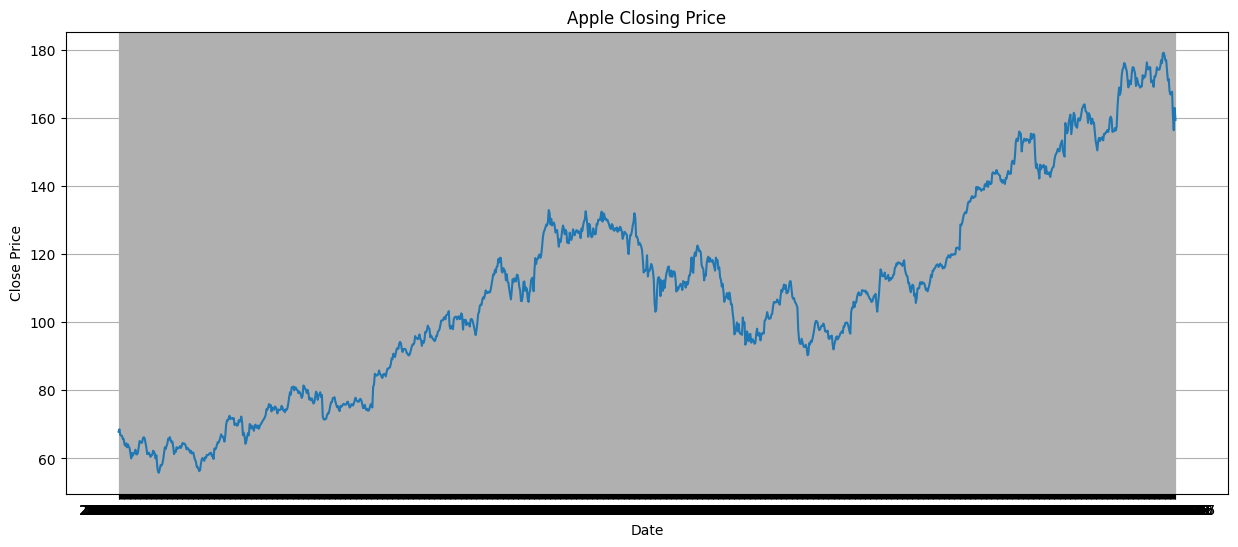

In [17]:
#plot closing price
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(aapl['date'], aapl['close'])

plt.title('Apple Closing Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)

plt.show()

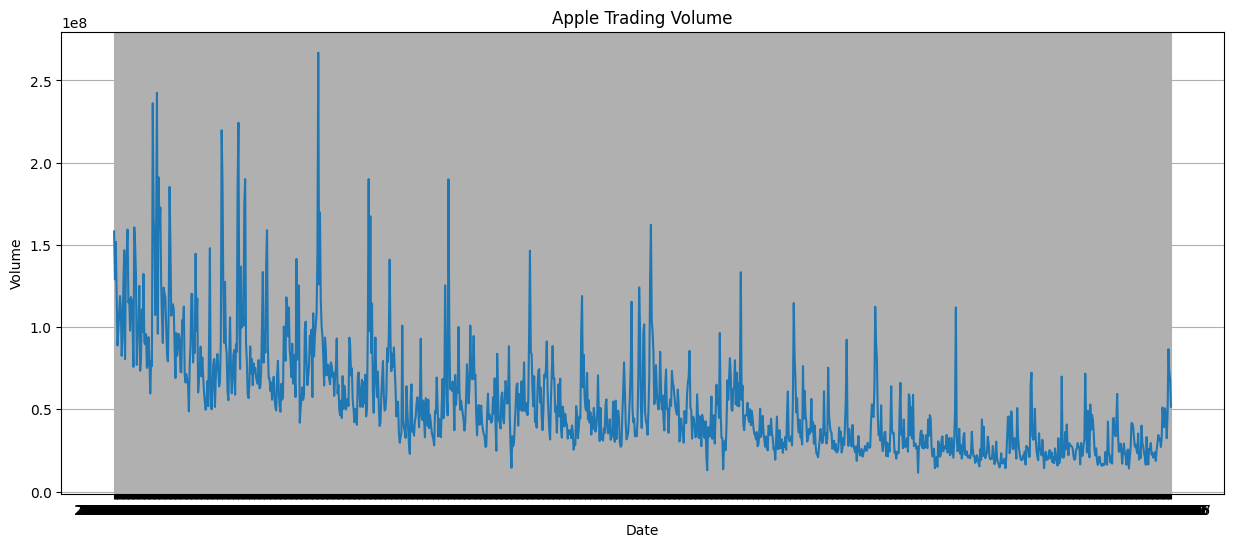

In [18]:
#Plot Trading Volume
plt.figure(figsize=(15,6))

plt.plot(aapl['date'], aapl['volume'])

plt.title('Apple Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)

plt.show()

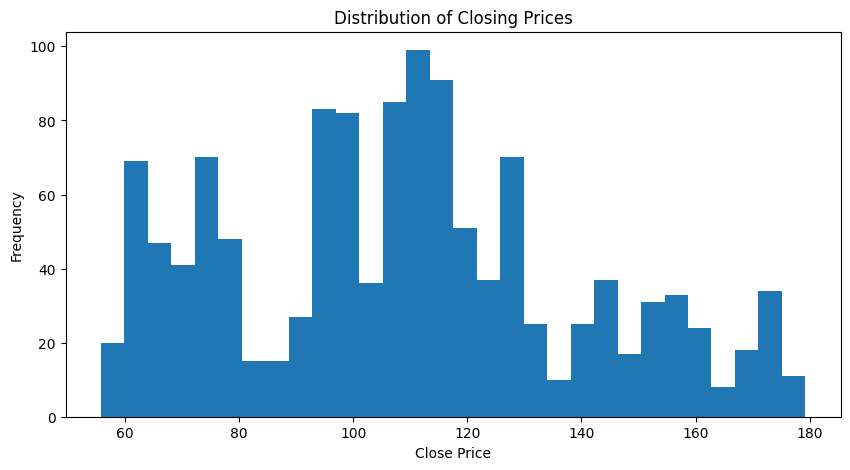

In [19]:
#Check Close Price Distribution
plt.figure(figsize=(10,5))

plt.hist(aapl['close'], bins=30)

plt.title('Distribution of Closing Prices')
plt.xlabel('Close Price')
plt.ylabel('Frequency')

plt.show()

**Correlation Analysis**

In [20]:
corr = aapl[['open','high','low','close','volume']].corr()

corr

,open,high,low,close,volume
open,1.000000,0.999584,0.999515,0.999118,-0.617862
high,0.999584,1.000000,0.999382,0.999584,-0.612622
low,0.999515,0.999382,1.000000,0.999614,-0.625910
close,0.999118,0.999584,0.999614,1.000000,-0.620290
volume,-0.617862,-0.612622,-0.625910,-0.620290,1.000000


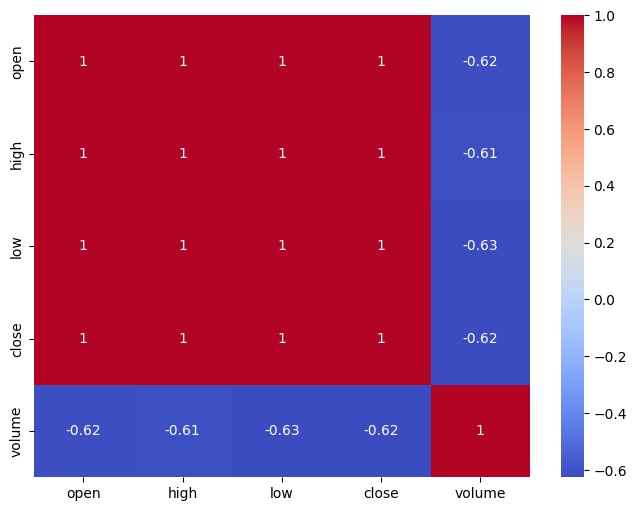

In [21]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

**Create the Time Series**

In [22]:
close_data = aapl[["close"]]
close_data.head()

,close
1259,67.8542
1260,68.5614
1261,66.8428
1262,66.7156
1263,66.6556


In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(close_data)

scaled_data[:5]

array([[0.0977103 ],
       [0.103438  ],
       [0.08951884],
       [0.08848863],
       [0.08800268]])

In [24]:
scaled_data.min(), scaled_data.max()

(np.float64(0.0), np.float64(1.0))

**Create Sliding Windows**

In [25]:
import numpy as np
def create_sequences(data, time_step=60):

  X = []
  y = []

  for i in range(time_step, len(data)):
    X.append(data[i-time_step:i, 0])
    y.append(data[i, 0])
  return np.array(X), np.array(y)

In [26]:
X, y = create_sequences(scaled_data, 60)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1199, 60)
y shape: (1199,)


In [27]:
print(X[0])
print(y[0])

[0.0977103  0.103438   0.08951884 0.08848863 0.08800268 0.08056363
 0.08036683 0.06747788 0.06424956 0.06974563 0.0604778  0.06761637
 0.06252526 0.05885797 0.046212   0.03415564 0.04699113 0.04064871
 0.04634158 0.04765769 0.05477358 0.0438511  0.04375877 0.04856074
 0.06147237 0.07542636 0.07400334 0.07121481 0.07196641 0.08258842
 0.08452006 0.08169265 0.07121481 0.06031582 0.0444067  0.04542719
 0.04797032 0.04302985 0.03780024 0.04128287 0.04217377 0.05225152
 0.05067786 0.0454361  0.033924   0.0413177  0.01419696 0.00175913
 0.         0.00941847 0.01804971 0.01727706 0.02065277 0.03086415
 0.04580704 0.06045431 0.0564169  0.06362512 0.06878507 0.08119942]
0.0788255618161805


**Train-Test Split**

In [28]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape)
print(X_test.shape)

(959, 60)
(240, 60)


In [29]:
X_train.shape

(959, 60)

**Reshape for LSTM**

In [30]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print(X_train.shape)
print(X_test.shape)

(959, 60, 1)
(240, 60, 1)


**Convert NumPy Arrays to PyTorch Tensors**

In [31]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(X_train.shape)
print(y_train.shape)

torch.Size([959, 60, 1])
torch.Size([959])


**Create DataLoaders**

In [32]:
from torch.utils.data import TensorDataset, DataLoader


train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

**Define the LSTM Model**

In [33]:
import torch.nn as nn

class StockLSTM(nn.Module):

  def __init__(self):

    super().__init__()

    self.lstm = nn.LSTM(
        input_size=1,
        hidden_size=50,
        num_layers=2,
        dropout=0.2,
        batch_first=True
    )

    self.fc = nn.Linear(50, 1)

  def forward(self, x):

        out, (hn, cn) = self.lstm(x)

        out = out[:, -1, :]

        out = self.fc(out)

        return out

**Create model-->Loss Fuction-->Optimizer**

In [34]:
model = StockLSTM()
print(model)

criterion = nn.MSELoss()

import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

StockLSTM(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


**Training Loop**

In [35]:

epochs = 20

for epoch in range(epochs):
  model.train()

  running_loss = 0

  for X_batch, y_batch in train_loader:

    optimizer.zero_grad()

    outputs = model(X_batch)

    loss = criterion(
        outputs.squeeze(),
        y_batch
    )

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {running_loss/len(train_loader):.6f}"
    )


Epoch [1/20] Loss: 0.000499
Epoch [1/20] Loss: 0.000764
Epoch [1/20] Loss: 0.001362
Epoch [1/20] Loss: 0.001962
Epoch [1/20] Loss: 0.002787
Epoch [1/20] Loss: 0.003372
Epoch [1/20] Loss: 0.003717
Epoch [1/20] Loss: 0.004088
Epoch [1/20] Loss: 0.004950
Epoch [1/20] Loss: 0.005968
Epoch [1/20] Loss: 0.007081
Epoch [1/20] Loss: 0.008028
Epoch [1/20] Loss: 0.009417
Epoch [1/20] Loss: 0.010322
Epoch [1/20] Loss: 0.011594
Epoch [1/20] Loss: 0.012067
Epoch [1/20] Loss: 0.012127
Epoch [1/20] Loss: 0.012721
Epoch [1/20] Loss: 0.014700
Epoch [1/20] Loss: 0.016177
Epoch [1/20] Loss: 0.017446
Epoch [1/20] Loss: 0.019697
Epoch [1/20] Loss: 0.020437
Epoch [1/20] Loss: 0.021143
Epoch [1/20] Loss: 0.021516
Epoch [1/20] Loss: 0.021564
Epoch [1/20] Loss: 0.021753
Epoch [1/20] Loss: 0.022259
Epoch [1/20] Loss: 0.023004
Epoch [1/20] Loss: 0.025322
Epoch [2/20] Loss: 0.001808
Epoch [2/20] Loss: 0.003764
Epoch [2/20] Loss: 0.004704
Epoch [2/20] Loss: 0.005297
Epoch [2/20] Loss: 0.005524
Epoch [2/20] Loss: 0

**Evaluate**

In [36]:
model.eval()

predictions = []

with torch.no_grad():

 for X_batch, _ in test_loader:

  preds = model(X_batch)

  predictions.extend(
            preds.squeeze().numpy()
        )

**Convert Back to Real Prices**

In [37]:
predictions = np.array(predictions)

predictions = scaler.inverse_transform(
    predictions.reshape(-1,1)
)

actual = scaler.inverse_transform(
    y_test.numpy().reshape(-1,1)
)


**Calculate RMSE**

In [38]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(
    mean_squared_error(actual, predictions)
)

print("RMSE:", rmse)

RMSE: 5.119381499781748


**Visualize Results**

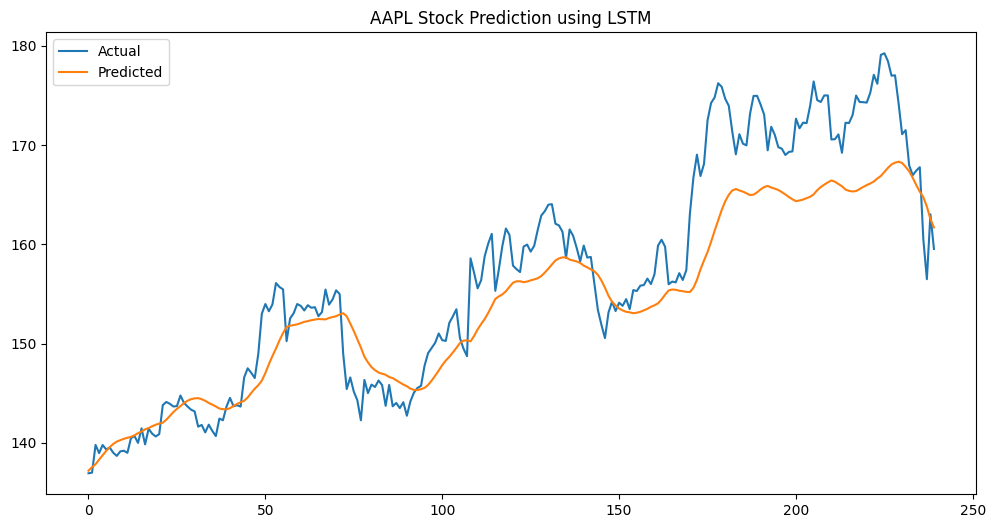

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(actual, label="Actual")
plt.plot(predictions, label="Predicted")

plt.legend()
plt.title("AAPL Stock Prediction using LSTM")
plt.show()